In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc


In [46]:
# Ensure the output directory exists
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def evaluate_model(model, model_name, X_test, y_test):
    print("=" * 60)
    print(f"🔍 Evaluating Model: {model_name}\n")

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)

    # Classification Report
    report = classification_report(y_test, y_pred, digits=4)

    print(f"✅ Accuracy:             {acc:.4f}")
    print(f"✅ Precision:           {prec:.4f}")
    print(f"✅ Recall:              {rec:.4f}")
    print(f"❗ False Positive Rate: {fpr:.4f}")
    print("\n📄 Classification Report:\n")
    print(report)

    # Save classification report
    report_path = os.path.join(OUTPUT_DIR, f"{model_name}_report.txt")
    with open(report_path, "w") as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Accuracy: {acc:.4f}\n")
        f.write(f"Precision: {prec:.4f}\n")
        f.write(f"Recall: {rec:.4f}\n")
        f.write(f"False Positive Rate: {fpr:.4f}\n\n")
        f.write(report)
    print(f"💾 Report saved to: {report_path}")

    # Plot and save confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal (0)', 'Attack (1)'],
                yticklabels=['Normal (0)', 'Attack (1)'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()

    cm_path = os.path.join(OUTPUT_DIR, f"{model_name}_confusion_matrix.png")
    plt.savefig(cm_path)
    plt.show()
    print(f"🖼️ Confusion matrix saved to: {cm_path}")
    print("✅ Evaluation complete.")
    print("=" * 60 + "\n")


## Data Preprocessing

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load raw data
train_path = '../data/NSL-KDD/KDDTrain+.TXT'
test_path = '../data/NSL-KDD/KDDTest+.TXT'

column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "target", "difficulty"
]

df_train = pd.read_csv(train_path, header=None, names=column_names)
df_test = pd.read_csv(test_path, header=None, names=column_names)

# Merge and preprocess
df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

# One-hot encode categorical features
cat_cols = ["protocol_type", "service", "flag"]
df = pd.get_dummies(df, columns=cat_cols)

# Encode labels (0 = normal, 1 = attack)
df['target_binary'] = df['target'].apply(lambda x: 0 if x == 'normal' else 1)

# Features and target
X = df.drop(['target', 'difficulty', 'target_binary'], axis=1)
y = df['target_binary']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets (80/20), stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)


## Logistic Regression Model

🔍 Evaluating Model: LogisticRegression

✅ Accuracy:             0.9562
✅ Precision:           0.9646
✅ Recall:              0.9437
❗ False Positive Rate: 0.0321

📄 Classification Report:

              precision    recall  f1-score   support

           0     0.9488    0.9679    0.9582     15411
           1     0.9646    0.9437    0.9540     14293

    accuracy                         0.9562     29704
   macro avg     0.9567    0.9558    0.9561     29704
weighted avg     0.9564    0.9562    0.9562     29704

💾 Report saved to: output\LogisticRegression_report.txt


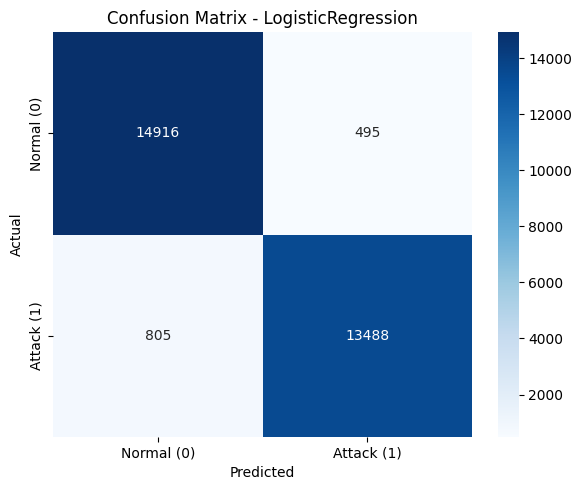

🖼️ Confusion matrix saved to: output\LogisticRegression_confusion_matrix.png
✅ Evaluation complete.



In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Train
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
log_reg.fit(X_train, y_train)

evaluate_model(log_reg, "LogisticRegression", X_test, y_test)

## 🌲 Random Forest

🔍 Evaluating Model: RandomForest

✅ Accuracy:             0.9961
✅ Precision:           0.9975
✅ Recall:              0.9943
❗ False Positive Rate: 0.0023

📄 Classification Report:

              precision    recall  f1-score   support

           0     0.9948    0.9977    0.9962     15411
           1     0.9975    0.9943    0.9959     14293

    accuracy                         0.9961     29704
   macro avg     0.9961    0.9960    0.9961     29704
weighted avg     0.9961    0.9961    0.9961     29704

💾 Report saved to: output\RandomForest_report.txt


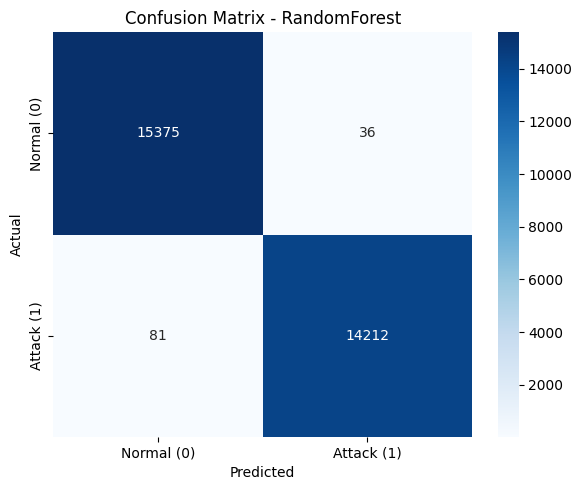

🖼️ Confusion matrix saved to: output\RandomForest_confusion_matrix.png
✅ Evaluation complete.



In [50]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
evaluate_model(rf, "RandomForest", X_test, y_test)

## 🌳 Decision Tree

🔍 Evaluating Model: DecisionTree

✅ Accuracy:             0.9949
✅ Precision:           0.9943
✅ Recall:              0.9950
❗ False Positive Rate: 0.0053

📄 Classification Report:

              precision    recall  f1-score   support

           0     0.9954    0.9947    0.9951     15411
           1     0.9943    0.9950    0.9947     14293

    accuracy                         0.9949     29704
   macro avg     0.9949    0.9949    0.9949     29704
weighted avg     0.9949    0.9949    0.9949     29704

💾 Report saved to: output\DecisionTree_report.txt


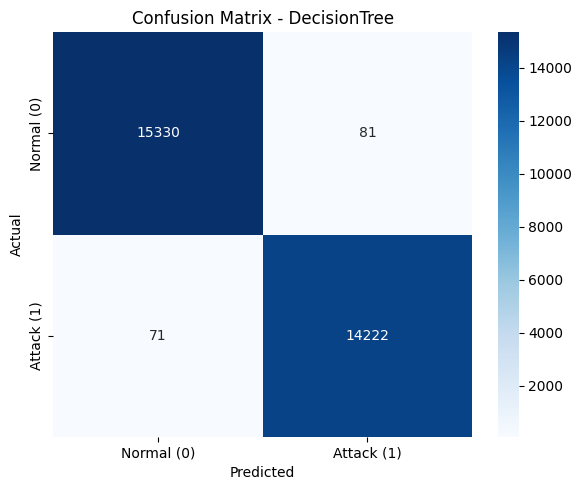

🖼️ Confusion matrix saved to: output\DecisionTree_confusion_matrix.png
✅ Evaluation complete.



In [51]:
dt = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=None,  # or set a value like 20
    random_state=42
)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
evaluate_model(dt, "DecisionTree", X_test, y_test)

In [52]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, Input
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 1. Load full dataset (Train + Test combined)
# train_path = '../data/NSL-KDD/KDDTrain+.TXT'
# test_path = '../data/NSL-KDD/KDDTest+.TXT'

# column_names = [
#     "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
#     "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
#     "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
#     "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
#     "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
#     "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
#     "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
#     "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
#     "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
#     "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "target", "difficulty"
# ]

# df_train = pd.read_csv(train_path, header=None, names=column_names)
# df_test = pd.read_csv(test_path, header=None, names=column_names)

# df_full = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

# # 2. One-hot encode categorical features
# df_full = pd.get_dummies(df_full, columns=["protocol_type", "service", "flag"])

# # 3. Encode target variable
# df_full["target_binary"] = df_full["target"].apply(lambda x: 0 if x == "normal" else 1)

# # 4. Drop unused columns
# X = df_full.drop(["target", "difficulty", "target_binary"], axis=1)
# y = df_full["target_binary"]

# # 5. Standardize features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X).astype("float32")
# y = y.astype("float32")

# # 6. Split into new train/test sets (80/20)
# X_train, X_test, y_train, y_test = train_test_split(
#     X_scaled, y, test_size=0.2, stratify=y, random_state=42
# )


## Build & Train the Neural Network

In [53]:
# from scikeras.wrappers import KerasClassifier
# from sklearn.inspection import permutation_importance
# from tensorflow.keras.layers import Input
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# import matplotlib.pyplot as plt

# from scikeras.wrappers import KerasClassifier

# def create_model():
#     model = Sequential([
#         Input(shape=(X_train.shape[1],)),
#         Dense(512, activation='relu'),
#         Dropout(0.4),
#         Dense(256, activation='relu'),
#         Dropout(0.3),
#         Dense(128, activation='relu'),
#         Dropout(0.2),
#         Dense(64, activation='relu'),
#         Dropout(0.2),
#         Dense(1, activation='sigmoid')
#     ])
#     model.compile(optimizer=Adam(learning_rate=0.0001), 
#                   loss='binary_crossentropy', 
#                   metrics=['accuracy'])
#     return model

# sklearn_model = KerasClassifier(
#     model=create_model,
#     epochs=50,
#     batch_size=256,
#     verbose=1,
#     validation_split=0.2,
#     callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
#     class_weight={0: 1, 1: 2}
# )

# # Train
# history = sklearn_model.fit(X_train, y_train)


In [54]:
# import matplotlib.pyplot as plt

# # Extract history from scikeras wrapper
# history_data = history.history_

# # Plot Accuracy
# plt.figure(figsize=(14, 5))

# plt.subplot(1, 2, 1)
# plt.plot(history_data['accuracy'], label='Training Accuracy')
# plt.plot(history_data['val_accuracy'], label='Validation Accuracy')
# plt.title('Model Accuracy over Epochs')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid(True)

# # Plot Loss
# plt.subplot(1, 2, 2)
# plt.plot(history_data['loss'], label='Training Loss')
# plt.plot(history_data['val_loss'], label='Validation Loss')
# plt.title('Model Loss over Epochs')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# plt.show()


## Evaluate the Model
(A) Predict & Compute Metrics

In [55]:
# # Predict
# y_pred_prob = sklearn_model.predict(X_test)
# y_pred = (y_pred_prob > 0.5).astype(int)

# # Metrics
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))

# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()
